In [15]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

#defining file path
file_path = ".../Shopper-Spectrum/data/online_retail.csv"

#Loading the dataset into a Pandas DataFrame
df = pd.read_csv(file_path, encoding='unicode_escape')


In [17]:
print(df.shape)

(541909, 8)


In [18]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [20]:
# creating a copy of dataframe to see difference
df_clean = df.copy()

# removing missing cutomerId rows
df_clean = df_clean.dropna(subset=['CustomerID'])

# removing cancelled invoices (invoice number starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# removing zero and negative quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# converting invoice date into datetime format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# checking difference
print(f"Original Dataset Shape: {df.shape}")
print(f"Cleaned Dataset Shape: {df_clean.shape}")

# double checking missing values now
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Original Dataset Shape: (541909, 8)
Cleaned Dataset Shape: (397884, 8)

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [21]:
# Checking and drop duplicate rows
duplicate_count = df_clean.duplicated().sum()
print(f"Found {duplicate_count} duplicate rows.droped in next step.")
df_clean = df_clean.drop_duplicates()

# Create the 'TotalAmount' column (Quantity * UnitPrice)
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Final check of our polished data
print(f"Final Polished Dataset Shape: {df_clean.shape}")
display(df_clean[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalAmount']].head())

Found 5192 duplicate rows.droped in next step.
Final Polished Dataset Shape: (392692, 9)


,InvoiceNo,Quantity,UnitPrice,TotalAmount
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


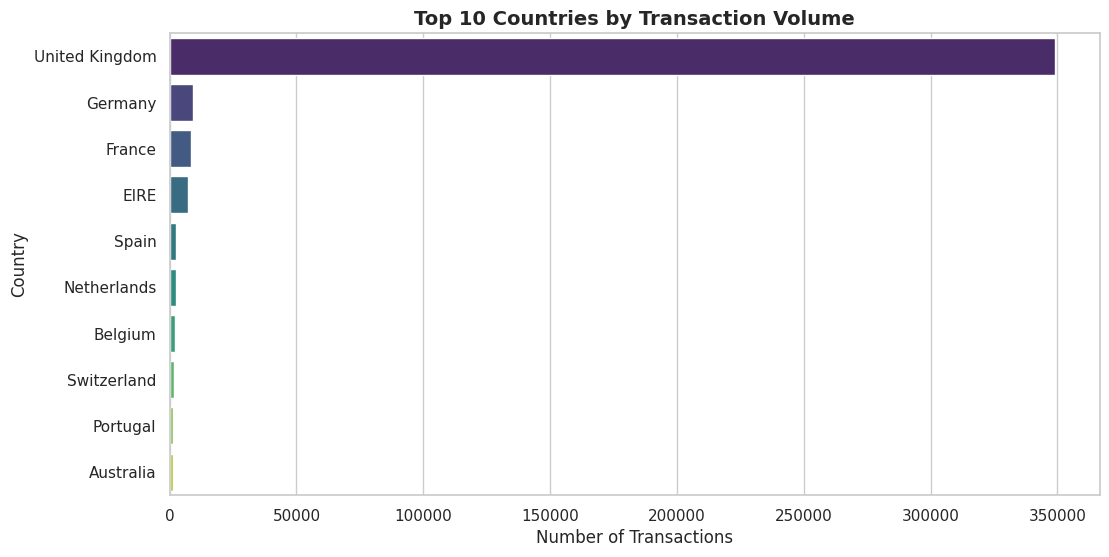

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Task 1 - Transaction Volume by Country (Top 10)

plt.figure(figsize=(12, 6))
# Counting how many times each country appears
country_counts = df_clean['Country'].value_counts().head(10)

sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis', hue=country_counts.index, legend=False)
plt.title('Top 10 Countries by Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()


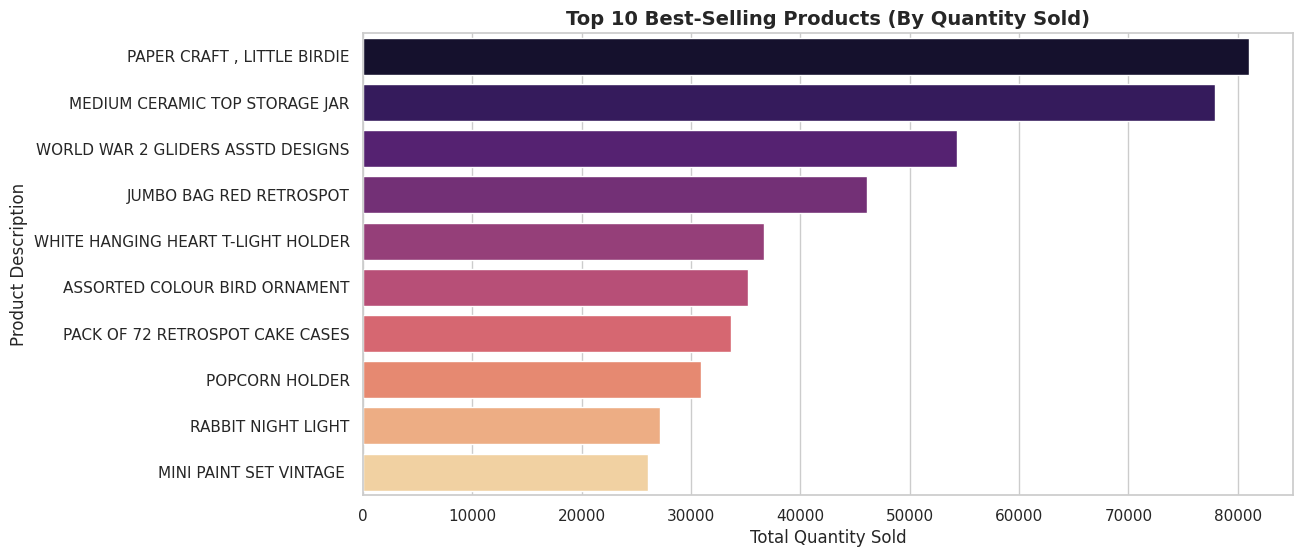

In [23]:
# Task 2 - Identifying top-selling products

plt.figure(figsize=(12, 6))
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='magma', legend=False)
plt.title('Top 10 Best-Selling Products (By Quantity Sold)', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.show()

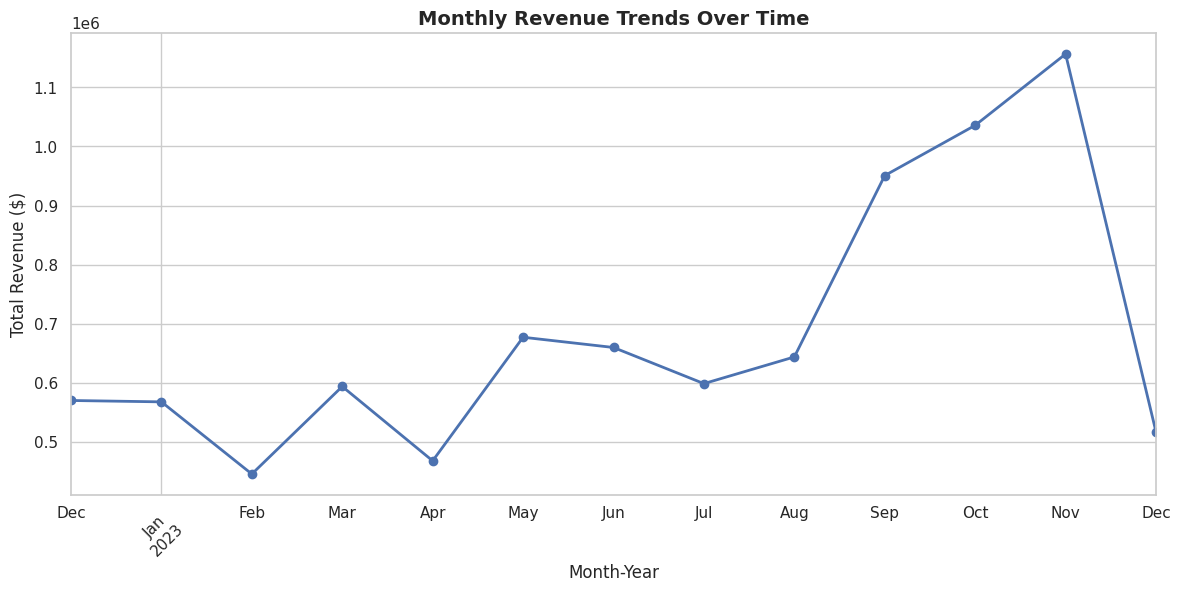

In [24]:

# Task 3 - Visualize purchase trends over time (Monthly Sales Volume)

# Creating a Year-Month column for easy grouping
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('YearMonth')['TotalAmount'].sum()

plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o', color='b', linewidth=2)
plt.title('Monthly Revenue Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()



In [25]:
# Task 4 - Inspect monetary distribution per transaction

print("--- Business Transaction Statistics ---")
print(df_clean['TotalAmount'].describe())

--- Business Transaction Statistics ---
count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64


In [26]:
# 1 - Defining a pinpoint reference date ("today') to calculate Recency
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Dataset snapshot date ('Today'): {snapshot_date}\n")

# 2 - Group by func onn CustomerID to calculate Recency, Frequency, and Monetary values
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Days since the last purchase
    'InvoiceNo': 'nunique',                                   # Number of the unique orders
    'TotalAmount': 'sum'                                      # Totaly spended
})

# 3 - Rename the columns to match RFM standard terminology
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# 4 - Inspect our new Customer- Level distributions
print("--- Customer-Level RFM Summary Statistics ---")
display(rfm.describe())

# 5 - Checking the first 5 customer profiles
print("\n--- First 5 Customer RFM Profiles ---")
display(rfm.head())

Dataset snapshot date ('Today'): 2023-12-10 12:50:00

--- Customer-Level RFM Summary Statistics ---


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000



--- First 5 Customer RFM Profiles ---


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


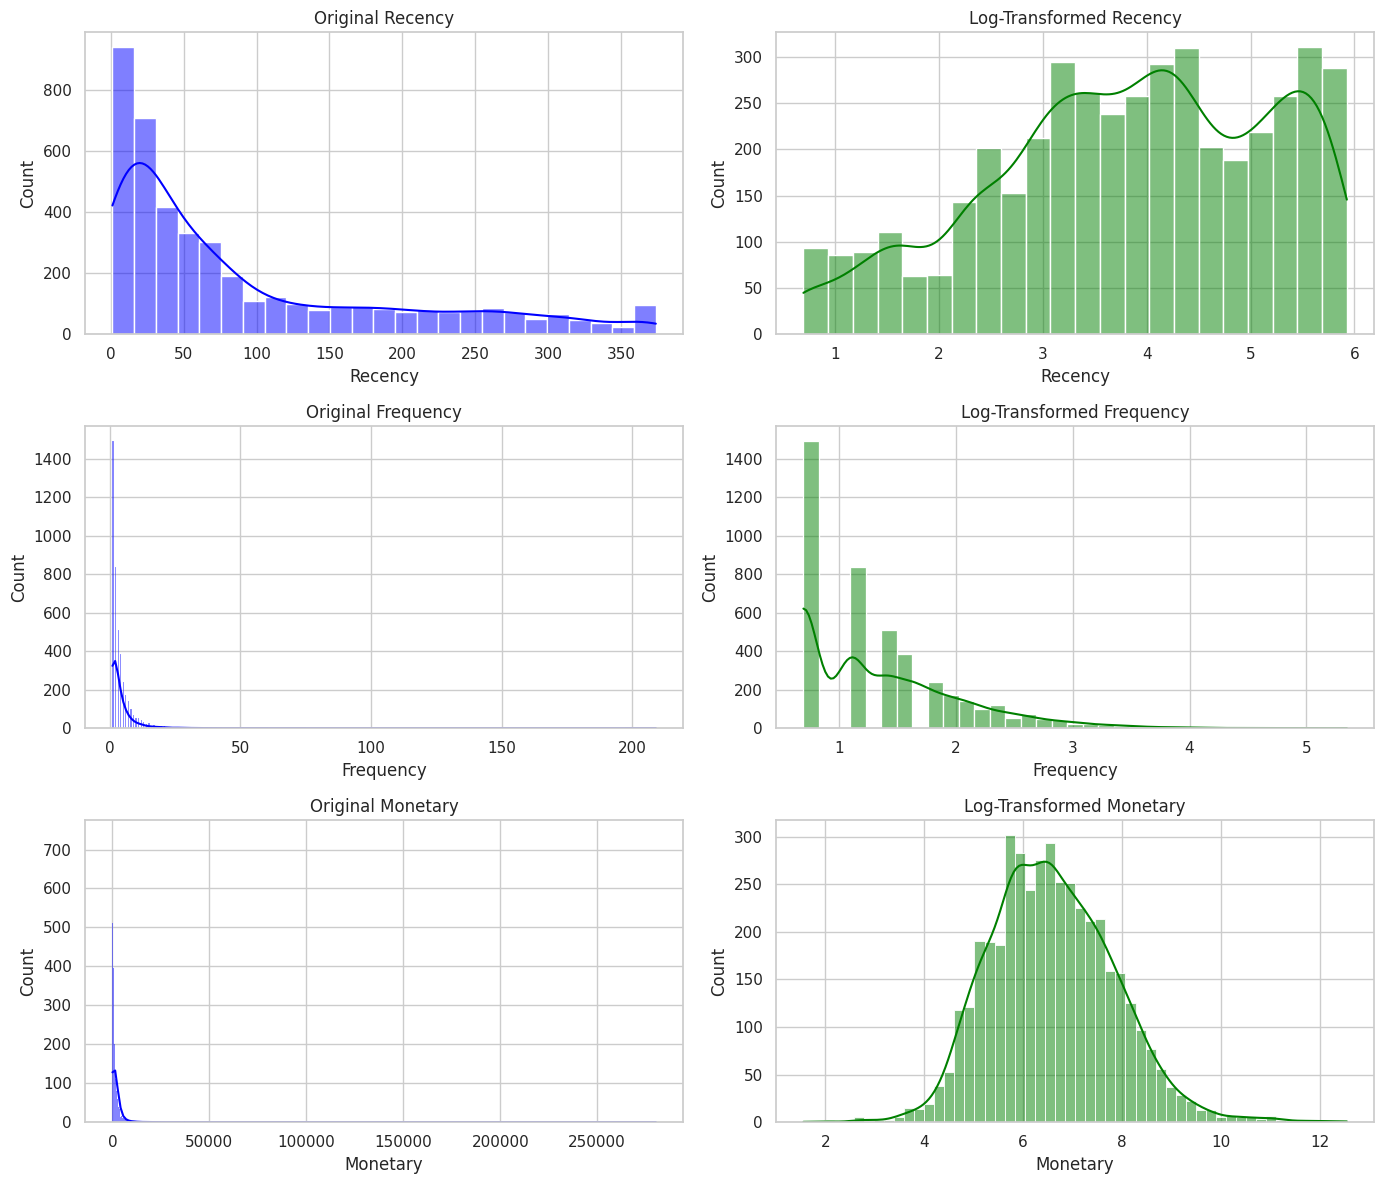

--- ----- New Transformed Summary Statistics ---


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,3.830734,1.345582,6.588562
std,1.340261,0.683104,1.258438
min,0.693147,0.693147,1.558145
25%,2.944439,0.693147,5.728418
50%,3.951244,1.098612,6.506636
75%,4.962845,1.791759,7.415535
max,5.926926,5.347108,12.543284


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1 - Creatinga a copy for the transformed data
rfm_transformed = rfm.copy()

# 2 - Apply Log Transformation (log1p handles log(0) safely if it appear)
rfm_transformed['Recency'] = np.log1p(rfm_transformed['Recency'])
rfm_transformed['Frequency'] = np.log1p(rfm_transformed['Frequency'])
rfm_transformed['Monetary'] = np.log1p(rfm_transformed['Monetary'])

# 3 - Visualize the distributions before vs after to confirm the fix
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Seeing Plot Recency
sns.histplot(rfm['Recency'], kde=True, ax=axes[0, 0], color='blue').set_title('Original Recency')
sns.histplot(rfm_transformed['Recency'], kde=True, ax=axes[0, 1], color='green').set_title('Log-Transformed Recency')

# Seeing the Plot Frequency
sns.histplot(rfm['Frequency'], kde=True, ax=axes[1, 0], color='blue').set_title('Original Frequency')
sns.histplot(rfm_transformed['Frequency'], kde=True, ax=axes[1, 1], color='green').set_title('Log-Transformed Frequency')

# Checking Plot Monetary
sns.histplot(rfm['Monetary'], kde=True, ax=axes[2, 0], color='blue').set_title('Original Monetary')
sns.histplot(rfm_transformed['Monetary'], kde=True, ax=axes[2, 1], color='green').set_title('Log-Transformed Monetary')

plt.tight_layout()
plt.show()

print("--- ----- New Transformed Summary Statistics ---")
display(rfm_transformed.describe())

In [28]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1 - Initialize the StandardScaler
scaler = StandardScaler()

# 2 - Fiting and transforming the log-transformed data
rfm_scaled_array = scaler.fit_transform(rfm_transformed)

# 3 - Converting the resulting numpy array back into a clean Pandas DataFrame for inspection
rfm_scaled = pd.DataFrame(rfm_scaled_array, index=rfm_transformed.index, columns=rfm_transformed.columns)

# 4 - Generate our single verification output
print("--- Standardized RFM Metrics (Should have Mean ≈ 0 and Std = 1) ---")
display(rfm_scaled.describe().round(3))

--- Standardized RFM Metrics (Should have Mean ≈ 0 and Std = 1) ---


,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-2.341,-0.955,-3.998
25%,-0.661,-0.955,-0.684
50%,0.090,-0.362,-0.065
75%,0.845,0.653,0.657
max,1.564,5.859,4.732


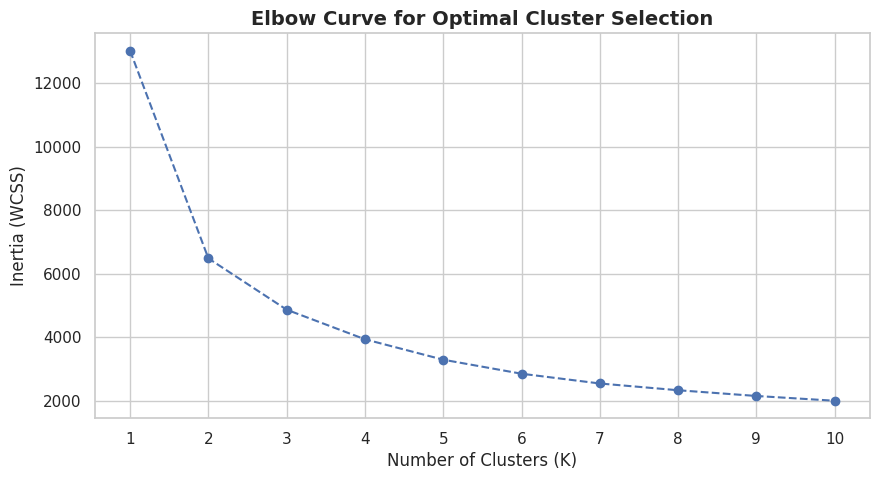

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1 - Creating an empty list to store the inertia (wcss) scores
wcss = []

# 2 - Run the KMeans for cluster sizes from 1 to 10
# NOTE - (We use random_state=42 to make sure our results are identical every time we run it)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# 3 - Plot the single required output: The Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Curve for Optimal Cluster Selection', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.xticks(range(1, 11))
plt.show()

In [30]:
# 1 - Initializing the KMeans with 4 clusters
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)

# 2 - Fiting  the model on the SCALED data and get the cluster labels
cluster_labels = kmeans_final.fit_predict(rfm_scaled)

# 3 - Attach the labels to our ORIGINAL (unscaled) RFM dataframe for interpretation
rfm['Cluster'] = cluster_labels

# 4 - Group by the new Cluster column and calculate the averages and size of each group
cluster_profiles = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count'] # 'count' tells us how many customers are in the segment
}).round(2)

# 5 - Display the profiles
print("--- Customer Cluster Profiles (Averages) ---")
display(cluster_profiles)

--- Customer Cluster Profiles (Averages) ---


Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0         12.17     13.75  8088.02   713
1        181.51      1.32   341.00  1622
2         17.70      2.19   557.32   837
3         71.64      4.08  1801.78  1166

In [ ]:
import joblib
import os

# 1 - Creating a dictionary mapping the cluster numbers to our business labels
cluster_mapping = {
    0: 'High-Value',
    1: 'At-Risk',
    2: 'Occasional',
    3: 'Regular'
}

# 2 -Apply the labels to a new 'Segment' column in our dataframe
rfm['Segment'] = rfm['Cluster'].map(cluster_mapping)

# 3 - Define the path to the models folder in correct Drive location
model_path = ".../Shopper-Spectrum/models/" 

# 4 - Saving the Machine Learning models so Streamlit can use them later!
joblib.dump(kmeans_final, os.path.join(model_path, 'kmeans_model.pkl'))
joblib.dump(scaler, os.path.join(model_path, 'scaler.pkl'))

print("Customer Segments Labeled!")
print("KMeans and Scaler models safely exported to the Drive!")
print("\n--- Final Customer Profiles ---")
display(rfm[['Recency', 'Frequency', 'Monetary', 'Segment']].head())

Customer Segments Labeled!
KMeans and Scaler models safely exported to the Drive!

--- Final Customer Profiles ---


,Recency,Frequency,Monetary,Segment
CustomerID,,,,
12346.0,326,1,77183.60,Regular
12347.0,2,7,4310.00,High-Value
12348.0,75,4,1797.24,Regular
12349.0,19,1,1757.55,Occasional
12350.0,310,1,334.40,At-Risk


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import os

# 1 - Create the Customer-Item Matrix (Rows = Customers, Columns = Products)
print("Building matrix... (This task may take a few time due to the large dataset)")
customer_item_matrix = df_clean.pivot_table(index='CustomerID', columns='Description', values='Quantity', aggfunc='sum').fillna(0)

# 2 - Convert to binary (1 if they ever bought it, 0 if not). to improves recommendation accuracy.
customer_item_matrix = (customer_item_matrix > 0).astype(int)

# 3 - Calculate Cosine Similarity (We use .T to transpose the matrix so we compare products to products)
item_similarity_array = cosine_similarity(customer_item_matrix.T)

# 4 - Convert back to a DataFrame with product names as rows and columns
item_similarity_df = pd.DataFrame(item_similarity_array, index=customer_item_matrix.columns, columns=customer_item_matrix.columns)

# 5 - Testing the Recommendation Engine!
test_product = "GREEN VINTAGE SPOT BEAKER"
print(f"\n--- Top 5 Recommendations for '{test_product}' ---")

# Sort similarities highest to lowest, skip index 0 (the product comparing to itself = 1.0), grab next 5
recommendations = item_similarity_df[test_product].sort_values(ascending=False).iloc[1:6]
print(recommendations)

# 6 - Save the matrix for the Streamlit app

model_path = ".../Shopper-Spectrum/models/"

joblib.dump(item_similarity_df, os.path.join(model_path, 'similarity_matrix.pkl'))
print("\n Similarity Matrix safely exported to Drive folder location!")

Building matrix... (This task may take a few time due to the large dataset)

--- Top 5 Recommendations for 'GREEN VINTAGE SPOT BEAKER' ---
Description
PINK VINTAGE SPOT BEAKER    0.716287
RED VINTAGE SPOT BEAKER     0.697182
BLUE VINTAGE SPOT BEAKER    0.691740
PINK  POLKADOT CUP          0.260524
RED RETROSPOT CUP           0.259853
Name: GREEN VINTAGE SPOT BEAKER, dtype: float64

 Similarity Matrix safely exported to Drive folder location!


In [33]:
from sklearn.metrics import silhouette_score
import plotly.express as px

# ---------------------------------------------------------
# Task 4 - Calculate Silhouette Score
# ---------------------------------------------------------
sil_score = silhouette_score(rfm_scaled, cluster_labels)
print(f" Silhouette Score for 4 clusters: {sil_score:.3f}")
print("(Note: A score closer to 1 is better, meaning clusters are well separated)")
print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# Task 6 - Visualize clusters in 3D
# ---------------------------------------------------------
# We attach the segment labels to our transformed data for plotting
rfm_transformed['Segment'] = rfm['Segment']

# Create an interactive 3D scatter plot
fig = px.scatter_3d(
    rfm_transformed,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='Segment',
    color_discrete_map={
        'High-Value': 'green',
        'Regular': 'blue',
        'Occasional': 'orange',
        'At-Risk': 'red'
    },
    opacity=0.7,
    title='3D Customer Segmentation (Log-Transformed RFM)',
    labels={'Recency': 'Log(Recency)', 'Frequency': 'Log(Frequency)', 'Monetary': 'Log(Monetary)'}
)

# Make the plot
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40), scene=dict(
                    xaxis_title='Recency (Days)',
                    yaxis_title='Frequency (Orders)',
                    zaxis_title='Monetary (Spend)'))
fig.show()

 Silhouette Score for 4 clusters: 0.338
(Note: A score closer to 1 is better, meaning clusters are well separated)


